<a href="https://colab.research.google.com/github/sri-kovi-data-analyst/canadian-consumer-borrowing-analysis/blob/main/notebooks/canadian_consumer_borrowing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Pandas helps us work with tables.
import pandas as pd

# NumPy helps us perform calculations.
import numpy as np

# Matplotlib helps us create charts.
import matplotlib.pyplot as plt

# Download four monthly banking series from the Bank of Canada.
# Requested period: October 2023 to September 2026.
# The latest months may not yet be published.
url = (
    "https://www.bankofcanada.ca/valet/observations/"
    "V36867,V36868,V36869,V36724/csv"
    "?start_date=2023-10-01&end_date=2026-09-30"
)

# The official CSV contains introductory metadata.
# Read everything into five columns, then keep only valid dated rows.
columns = [
    "date",
    "personal_loans",
    "credit_cards",
    "lines_of_credit",
    "residential_mortgages"
]

df = pd.read_csv(
    url,
    header=None,
    names=columns,
    on_bad_lines="error"
)

# Convert valid dates. Metadata and headings become missing dates.
df["date"] = pd.to_datetime(
    df["date"],
    format="%Y-%m-%d",
    errors="coerce"
)

# Remove the introductory metadata rows.
df = df.dropna(subset=["date"]).copy()

# Display the first five actual observations.
display(df.head())

,date,personal_loans,credit_cards,lines_of_credit,residential_mortgages
10,2023-10-01,1601099,122711,96078,360227
11,2023-11-01,1605238,122632,99602,360790
12,2023-12-01,1606744,122390,99850,361766
13,2024-01-01,1606516,122098,96420,360784
14,2024-02-01,1609015,122116,97255,363372


In [2]:
# Store the balance columns so we can reuse them.
balance_columns = columns[1:]

# Convert balances from text into numbers.
for column in balance_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Put the observations in chronological order.
df = df.sort_values("date").reset_index(drop=True)

# Check the data before doing calculations.
print("Number of monthly observations:", len(df))
print("\nMissing values:")
print(df.isna().sum())

if df.empty:
    raise ValueError("No observations were loaded.")

if df[balance_columns].isna().any().any():
    raise ValueError("Some balances are missing. Inspect the dataset.")

if df["date"].duplicated().any():
    raise ValueError("Duplicate dates were found.")

# Check that no months are missing between the first and last observation.
months = df["date"].dt.to_period("M")
expected_months = pd.period_range(months.min(), months.max(), freq="M")

if months.duplicated().any() or len(months) != len(expected_months):
    raise ValueError("Duplicate or missing months were found.")

# Original balances are in CAD millions.
# Divide by 1,000 to express them in CAD billions.
df[balance_columns] = df[balance_columns] / 1000

print("\nFirst month:", months.iloc[0])
print("Last month:", months.iloc[-1])
print("Balances are now in CAD billions.")

display(df.head())

Number of monthly observations: 34

Missing values:
date                     0
personal_loans           0
credit_cards             0
lines_of_credit          0
residential_mortgages    0
dtype: int64

First month: 2023-10
Last month: 2026-07
Balances are now in CAD billions.


,date,personal_loans,credit_cards,lines_of_credit,residential_mortgages
0,2023-10-01,1601.099,122.711,96.078,360.227
1,2023-11-01,1605.238,122.632,99.602,360.790
2,2023-12-01,1606.744,122.390,99.850,361.766
3,2024-01-01,1606.516,122.098,96.420,360.784
4,2024-02-01,1609.015,122.116,97.255,363.372


In [3]:
# Extract the first and last observed balances.
starting_balances = df[balance_columns].iloc[0]
latest_balances = df[balance_columns].iloc[-1]

# Calculate the absolute and percentage changes.
balance_changes = latest_balances - starting_balances
growth_percentages = (
    (latest_balances / starting_balances) - 1
) * 100

# Build a summary table.
summary = pd.DataFrame({
    "starting_balance_billions": starting_balances,
    "latest_balance_billions": latest_balances,
    "change_billions": balance_changes,
    "growth_percent": growth_percentages
})

# Sort from highest to lowest percentage growth.
summary = summary.sort_values("growth_percent", ascending=False)

display(summary.round(2))

# Identify the category with the highest percentage growth.
fastest_category = summary["growth_percent"].idxmax()

print(
    "Highest percentage growth:",
    fastest_category.replace("_", " ").title()
)

,starting_balance_billions,latest_balance_billions,change_billions,growth_percent
residential_mortgages,360.23,447.49,87.27,24.23
lines_of_credit,96.08,112.47,16.40,17.07
personal_loans,1601.10,1739.51,138.41,8.64
credit_cards,122.71,127.91,5.20,4.23


Highest percentage growth: Residential Mortgages


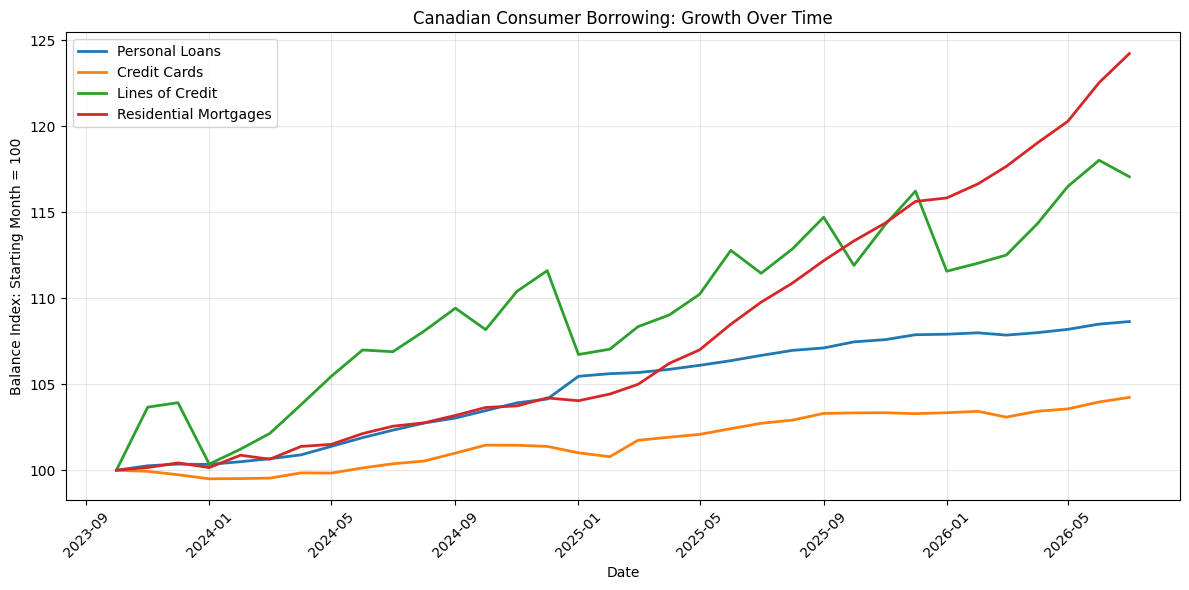

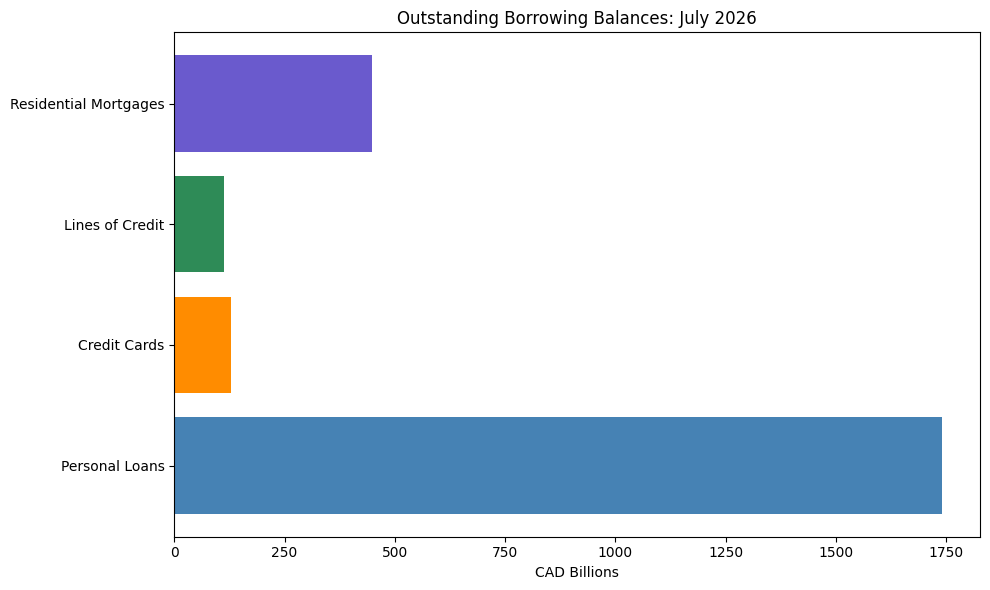

In [4]:
# Set readable category names.
labels = {
    "personal_loans": "Personal Loans",
    "credit_cards": "Credit Cards",
    "lines_of_credit": "Lines of Credit",
    "residential_mortgages": "Residential Mortgages"
}

# Divide each category by its starting balance, then multiply by 100.
indexed_balances = (
    df[balance_columns] / df[balance_columns].iloc[0]
) * 100

# Chart 1: Compare growth over time.
plt.figure(figsize=(12, 6))

for column in balance_columns:
    plt.plot(
        df["date"],
        indexed_balances[column],
        label=labels[column],
        linewidth=2
    )

plt.title("Canadian Consumer Borrowing: Growth Over Time")
plt.xlabel("Date")
plt.ylabel("Balance Index: Starting Month = 100")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("borrowing_growth.png", dpi=200)
plt.show()

# Chart 2: Compare the latest outstanding balances.
plt.figure(figsize=(10, 6))

plt.barh(
    [labels[column] for column in balance_columns],
    latest_balances.values,
    color=["steelblue", "darkorange", "seagreen", "slateblue"]
)

plt.title(
    f"Outstanding Borrowing Balances: "
    f"{df['date'].iloc[-1]:%B %Y}"
)
plt.xlabel("CAD Billions")
plt.tight_layout()

plt.savefig("latest_balances.png", dpi=200)
plt.show()

Average monthly credit-card growth: 0.13%
Largest monthly increase: March 2025 (0.95%)
Largest monthly decrease: January 2025 (-0.37%)


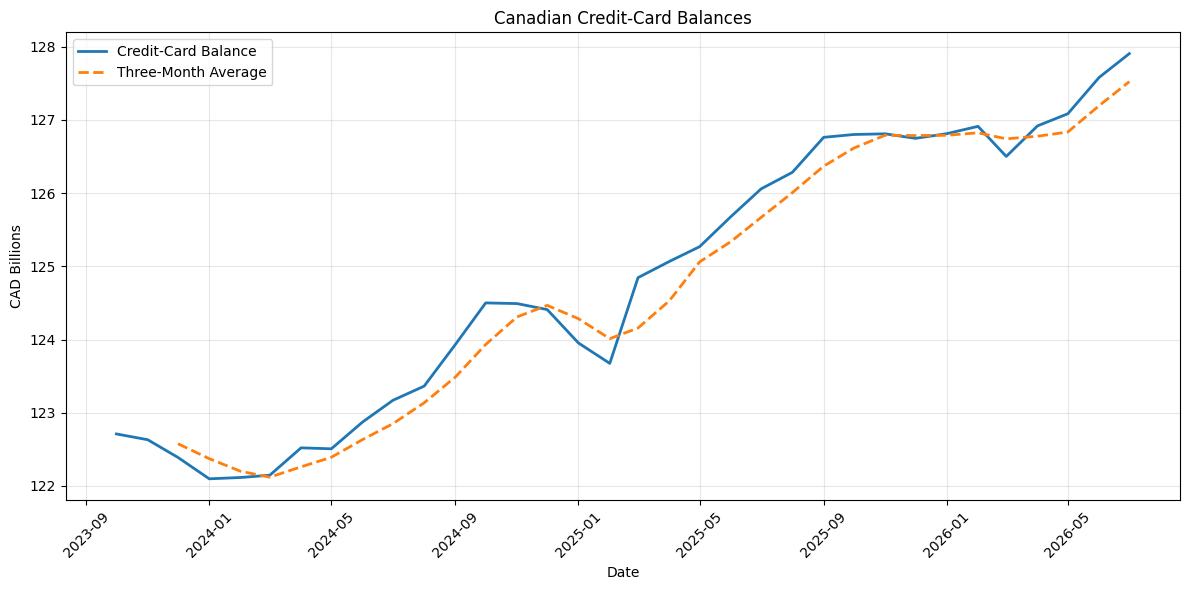

In [5]:
# Calculate the monthly percentage change in credit-card balances.
# The first month will be missing because there is no previous month.
df["credit_card_monthly_growth_pct"] = (
    df["credit_cards"].pct_change(fill_method=None) * 100
)

# Calculate a three-month average to smooth short-term movements.
df["credit_card_3_month_average"] = (
    df["credit_cards"].rolling(window=3).mean()
)

# Use NumPy to calculate the average valid monthly change.
valid_changes = df["credit_card_monthly_growth_pct"].dropna()

average_change = np.mean(valid_changes.to_numpy())

# Find the months with the largest increase and decrease.
highest_month = df.loc[
    df["credit_card_monthly_growth_pct"].idxmax()
]

lowest_month = df.loc[
    df["credit_card_monthly_growth_pct"].idxmin()
]

print(f"Average monthly credit-card growth: {average_change:.2f}%")

print(
    f"Largest monthly increase: {highest_month['date']:%B %Y} "
    f"({highest_month['credit_card_monthly_growth_pct']:.2f}%)"
)

print(
    f"Largest monthly decrease: {lowest_month['date']:%B %Y} "
    f"({lowest_month['credit_card_monthly_growth_pct']:.2f}%)"
)

# Plot actual balances and the smoother three-month average.
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["credit_cards"],
    label="Credit-Card Balance",
    linewidth=2
)

plt.plot(
    df["date"],
    df["credit_card_3_month_average"],
    label="Three-Month Average",
    linestyle="--",
    linewidth=2
)

plt.title("Canadian Credit-Card Balances")
plt.xlabel("Date")
plt.ylabel("CAD Billions")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("credit_card_trend.png", dpi=200)
plt.show()